# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
apple = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv')

In [ ]:
# Visualizamos las primeras filas:
print(apple.head())

         Date   Open   High    Low  Close    Volume  Adj Close
0  2014-07-08  96.27  96.80  93.92  95.35  65130000      95.35
1  2014-07-07  94.14  95.99  94.10  95.97  56305400      95.97
2  2014-07-03  93.67  94.10  93.20  94.03  22891800      94.03
3  2014-07-02  93.87  94.06  93.09  93.48  28420900      93.48
4  2014-07-01  93.52  94.07  93.13  93.52  38170200      93.52


### Step 3. Assign it to a variable apple and apply a head()

In [ ]:
#Already done in step 2

### Step 4.  Check out the type of the columns

In [4]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### Step 5. Transform the Date column as a datetime type and check the info()

In [ ]:
#Para transformar la columna "Date" y verificar toda la estructura del Dataframe (incluyendo los tipos de datos y valores nulos), se usa el siguiente código:

#Convertir la columna Date a tipo datetime:
apple.Date = pd.to_datetime(apple.Date)

#Verificar los cambios y la información general:
apple.info()

#RangeIndex: el número total de filas: 8.465
#Non-Null: confirma si hay valores faltantes en alguna columna
#Memory Usage: indica cuánta memoria RAM está ocupando el Dataframe

<class 'pandas.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8465 non-null   datetime64[us]
 1   Open       8465 non-null   float64       
 2   High       8465 non-null   float64       
 3   Low        8465 non-null   float64       
 4   Close      8465 non-null   float64       
 5   Volume     8465 non-null   int64         
 6   Adj Close  8465 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 463.1 KB


### Step 6.  Set the date as the index

In [7]:
#Establecer 'Date' como el índice:
apple.set_index('Date', inplace=True)

#Verificar el cambio mostrando las primeras filas:
print(apple.head())

             Open   High    Low  Close    Volume  Adj Close
Date                                                       
2014-07-08  96.27  96.80  93.92  95.35  65130000      95.35
2014-07-07  94.14  95.99  94.10  95.97  56305400      95.97
2014-07-03  93.67  94.10  93.20  94.03  22891800      94.03
2014-07-02  93.87  94.06  93.09  93.48  28420900      93.48
2014-07-01  93.52  94.07  93.13  93.52  38170200      93.52


### Step 7.  Is there any duplicate dates?

In [ ]:
#Dado que ya está establecido la columna Date como el índice del Dataframe, la forma de verificar duplicados es consultando la propiedad .is_unique del índice:

# Verificamos si el índice tiene valores únicos:
print(apple.index.is_unique)

#si el resultado es "True", significa que cada fila corresponde a un día de cotización distinto y no hay duplicado

True


### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [9]:
#Para lograr que el Dataframe comience con la fecha más antigua (12 de diciembre de 1980), se debe utilizar el método sort_index():

#Ordenar el índice de forma ascendente (de más antiguo a más reciente):
apple.sort_index(ascending=True, inplace=True)
#ascending=True: Coloca las fechas menores al principio
#inplace=True: Aplica el cambio directamente sobre la variable apple para que no tengas que reasignarla

#Comprobar el cambio:
print(apple.head())

             Open   High    Low  Close     Volume  Adj Close
Date                                                        
1980-12-12  28.75  28.87  28.75  28.75  117258400       0.45
1980-12-15  27.38  27.38  27.25  27.25   43971200       0.42
1980-12-16  25.37  25.37  25.25  25.25   26432000       0.39
1980-12-17  25.87  26.00  25.87  25.87   21610400       0.40
1980-12-18  26.63  26.75  26.63  26.63   18362400       0.41


### Step 9. Get the last business day of each month

In [ ]:
#Para obtener el último día hábil de cada mes a partir de tus datos, la forma más eficiente es utilizar el método resample() con la regla 'BME' (Business Month End)
#Resampleamos los datos para obtener el último día hábil de cada mes:

#Tomamos el promedio (mean) de los valores para esos meses:
apple_month = apple.resample('BME').mean()
#resample('BME'): Agrupa los datos basándose en el "Business Month end" (último día laboral del mes)
#.mean(): Al agrupar, se usa la media con los valores de los otros días del mes (Open, Close, etc.) para suavizar la serie

#Mostramos el resultado:
print(apple_month.head())

#Resultado:las fechas del índice ahora son siempre el último día hábil de cada mes

                 Open       High        Low      Close        Volume  \
Date                                                                   
1980-12-31  30.481538  30.567692  30.443077  30.443077  2.586252e+07   
1981-01-30  31.754762  31.826667  31.654762  31.654762  7.249867e+06   
1981-02-27  26.480000  26.572105  26.407895  26.407895  4.231832e+06   
1981-03-31  24.937727  25.016818  24.836364  24.836364  7.962691e+06   
1981-04-30  27.286667  27.368095  27.227143  27.227143  6.392000e+06   

            Adj Close  
Date                   
1980-12-31   0.473077  
1981-01-30   0.493810  
1981-02-27   0.411053  
1981-03-31   0.387727  
1981-04-30   0.423333  


### Step 10.  What is the difference in days between the first day and the oldest

In [ ]:
#Para calcular la diferencia en días entre la fecha más reciente (la última) y la más antigua (la primera), se puede restar directamente los valores del índice ahora 
#que ya están ordenados

#Se resta el último valor del índice menos el primero:
diferencia = apple.index.max() - apple.index.min()

print(diferencia)

#apple.index.max(): Obtiene la fecha más reciente (en este dataset, julio de 2014)
#apple.index.min(): Obtiene la fecha más antigua (diciembre de 1980)
#Resultado: Al ser objetos de tipo datetime, Pandas devuelve un objeto Timedelta que indica el número total de días

12261 days 00:00:00


### Step 11.  How many months in the data we have?

In [14]:
#Puedes obtener el número total simplemente midiendo el largo (len) de ese Dataframe:
#Contar las filas del Dataframe mensual:
cantidad_meses = len(apple_month)

print(f"Hay {cantidad_meses} meses en los datos")

Hay 404 meses en los datos


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

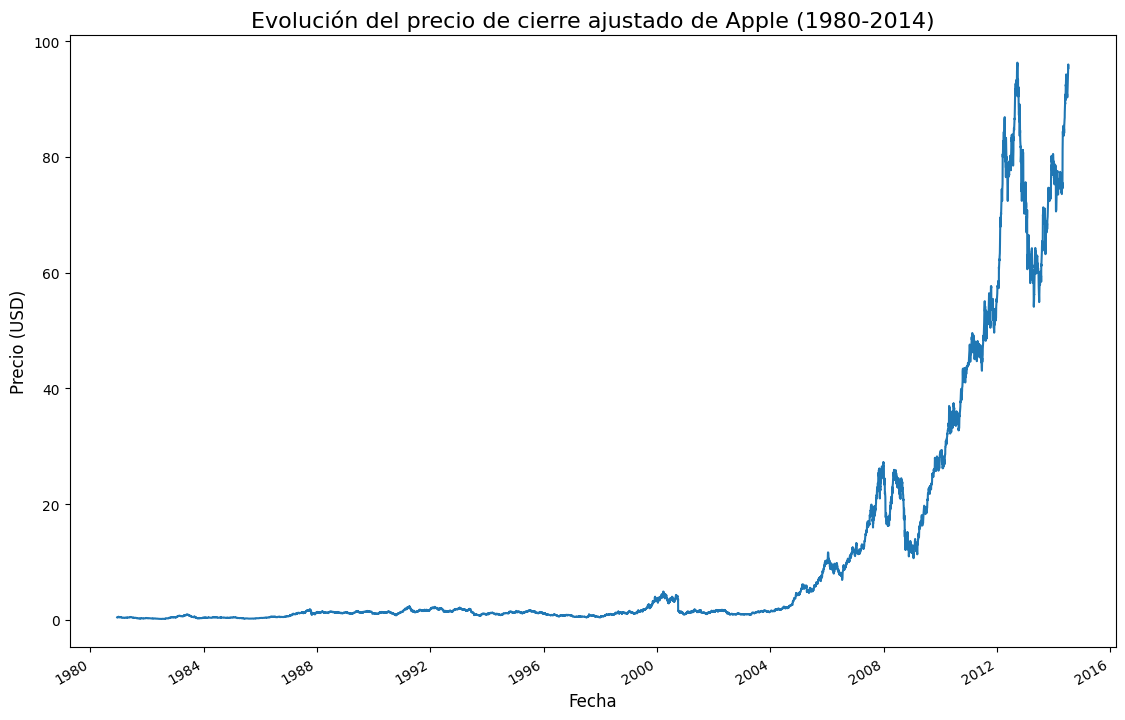

In [ ]:
#Para graficar la columna 'Adj Close' con las dimensiones específicas que pides, puedes usar el método .plot() directamente desde el DataFrame.

#Definimos el tamaño de la figura (ancho, alto):
plt.figure(figsize = (13.5, 9))

#Graficamos la columna 'Adj Close':
apple['Adj Close'].plot()

#Se añaden títulos y etiquetas para que se vea profesional:
plt.title('Evolución del precio de cierre ajustado de Apple (1980-2014)', fontsize = 16)
plt.xlabel('Fecha', fontsize = 12)
plt.ylabel('Precio (USD)', fontsize = 12)

#Para mostrar el gráfico:
plt.show()

#Tendencia: el gráfico se mantiene muy plano durante casi 20 años y explota hacia arriba a partir de los años 2000 (coincidiendo con el iPod y el iPhone)